# Societal Insight Mapping

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Load and concatenate data
def load_and_concatenate(path_or_pattern):
    # If a directory is provided, list CSV files inside it; otherwise treat as glob pattern
    if os.path.isdir(path_or_pattern):
        files = [os.path.join(path_or_pattern, f) for f in os.listdir(path_or_pattern) if f.endswith('.csv')]
    else:
        files = glob.glob(path_or_pattern)
    if not files:
        raise FileNotFoundError(f"No CSV files found matching: {path_or_pattern}")
    df_list = [pd.read_csv(file) for file in files]
    return pd.concat(df_list, ignore_index=True)

# Only load if not already defined to avoid overwriting existing DataFrames
if 'enrolment_df' not in globals():
    enrolment_df = load_and_concatenate('api_data_aadhar_enrolment/api_data_aadhar_enrolment_*/*.csv')
if 'demographic_df' not in globals():
    demographic_df = load_and_concatenate('api_data_aadhar_demographic/api_data_aadhar_demographic_*/*.csv')
if 'biometric_df' not in globals():
    biometric_df = load_and_concatenate('api_data_aadhar_biometric/api_data_aadhar_biometric_*/*.csv')

print("Enrolment Data Shape:", enrolment_df.shape)
print("Demographic Data Shape:", demographic_df.shape)
print("Biometric Data Shape:", biometric_df.shape)

Enrolment Data Shape: (1006029, 7)
Demographic Data Shape: (2071700, 6)
Biometric Data Shape: (1861108, 6)


In [9]:
# 'Aadhaar_Number' doesn't exist in these DataFrames; merge on common keys instead
merge_keys = ['date', 'state', 'district', 'pincode']

merged_df = enrolment_df.merge(demographic_df, on=merge_keys, how='inner') \
                        .merge(biometric_df, on=merge_keys, how='inner')

# Fill missing numeric values with median
num_cols = merged_df.select_dtypes(include=np.number).columns
merged_df[num_cols] = merged_df[num_cols].apply(lambda s: s.fillna(s.median()))

print("Merged Data Shape:", merged_df.shape)
merged_df.head()


Merged Data Shape: (756586, 11)


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_
0,01-04-2025,Punjab,Ludhiana,141007,374,110,25,206,2000,925,1404
1,01-04-2025,Punjab,Ludhiana,141007,374,110,25,206,2000,925,1404
2,01-04-2025,Madhya Pradesh,Ashok Nagar,473335,125,29,22,181,975,1418,587
3,01-04-2025,Madhya Pradesh,Ashok Nagar,473335,125,29,22,181,975,1418,587
4,01-04-2025,Jharkhand,Ranchi,834001,187,174,21,210,1855,1494,2283


## 3. Analyze Child Enrolment Delays

C:\Users\aruna\AppData\Local\Temp\ipykernel_27492\210196512.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=child_share_by_state.index, x=child_share_by_state.values, palette='viridis')


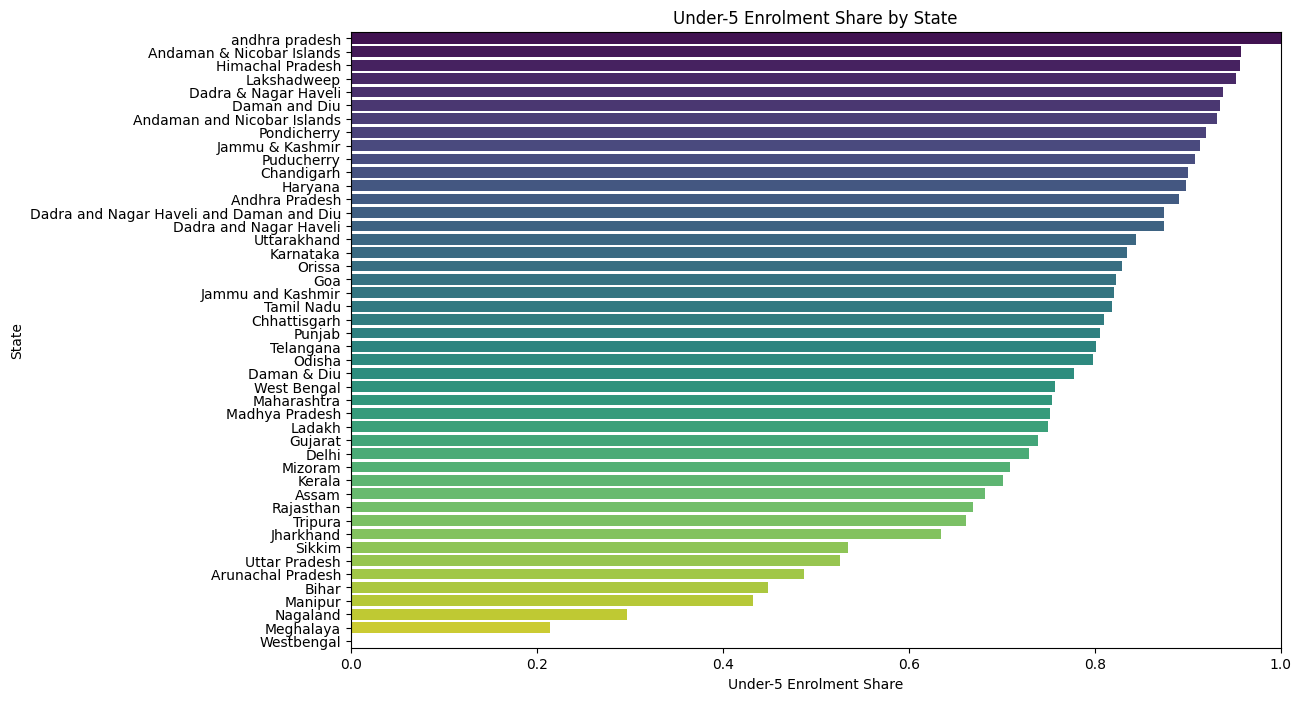

In [11]:
# There is no individual 'age' column in merged_df; use available aggregated counts.
# Compute share of under-5 enrolments by state.
child_enrolment_df = merged_df.copy()
child_enrolment_df['total_enrolment'] = child_enrolment_df[['age_0_5', 'age_5_17', 'age_18_greater']].sum(axis=1)

# Filter out rows with zero total to avoid division by zero
child_enrolment_df = child_enrolment_df[child_enrolment_df['total_enrolment'] > 0]

# Weighted child share per state = sum(age_0_5) / sum(total_enrolment)
state_totals = child_enrolment_df.groupby('state')[['age_0_5', 'total_enrolment']].sum()
child_share_by_state = (state_totals['age_0_5'] / state_totals['total_enrolment']).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(y=child_share_by_state.index, x=child_share_by_state.values, palette='viridis')
plt.title('Under-5 Enrolment Share by State')
plt.xlabel('Under-5 Enrolment Share')
plt.ylabel('State')
plt.xlim(0, 1)
plt.show()

## 4. Analyze Demographic Update Frequency

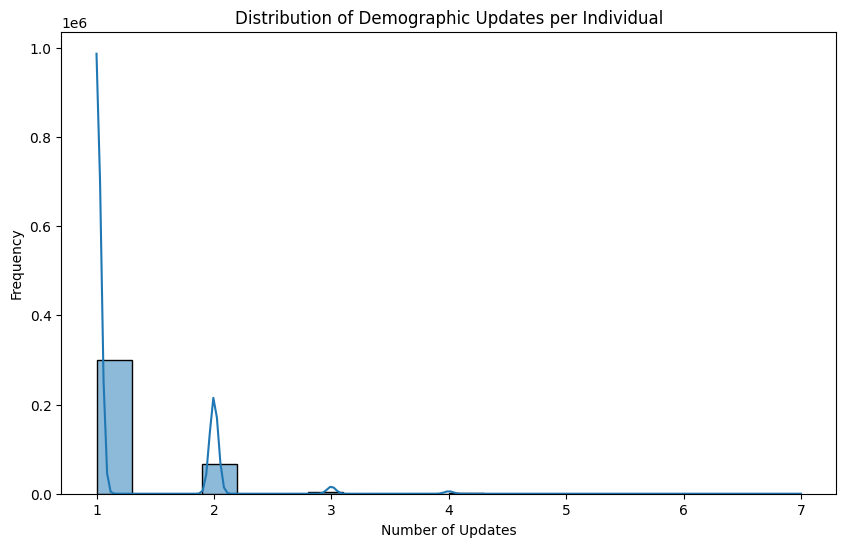

In [ ]:
if 'update_type' not in merged_df.columns:
    # Simulate update types
    update_choices = ['address', 'mobile', 'name', 'None']
    merged_df['update_type'] = np.random.choice(update_choices, size=len(merged_df), p=[0.2, 0.3, 0.1, 0.4])

demographic_updates = merged_df[merged_df['update_type'] != 'None']
update_counts = demographic_updates.groupby(merge_keys).size().reset_index(name='update_count')

# Analyze distribution
plt.figure(figsize=(10, 6))
sns.histplot(update_counts['update_count'], bins=20, kde=True)
plt.title('Distribution of Demographic Updates per Individual')
plt.xlabel('Number of Updates')
plt.ylabel('Frequency')
plt.show()

# Correlate with occupation (if available)
if 'occupation' in merged_df.columns:
    updates_with_occupation = pd.merge(update_counts, merged_df[merge_keys + ['occupation']].drop_duplicates(), on=merge_keys)
    avg_updates_by_occupation = updates_with_occupation.groupby('occupation')['update_count'].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(y=avg_updates_by_occupation.index, x=avg_updates_by_occupation.values)
    plt.title('Average Demographic Updates by Occupation')
    plt.xlabel('Average Number of Updates')
    plt.ylabel('Occupation')
    plt.show()

## 6. Analyze Rural Update Spikes

C:\Users\aruna\AppData\Local\Temp\ipykernel_27492\3411026812.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_updates = rural_updates.resample('M').size()


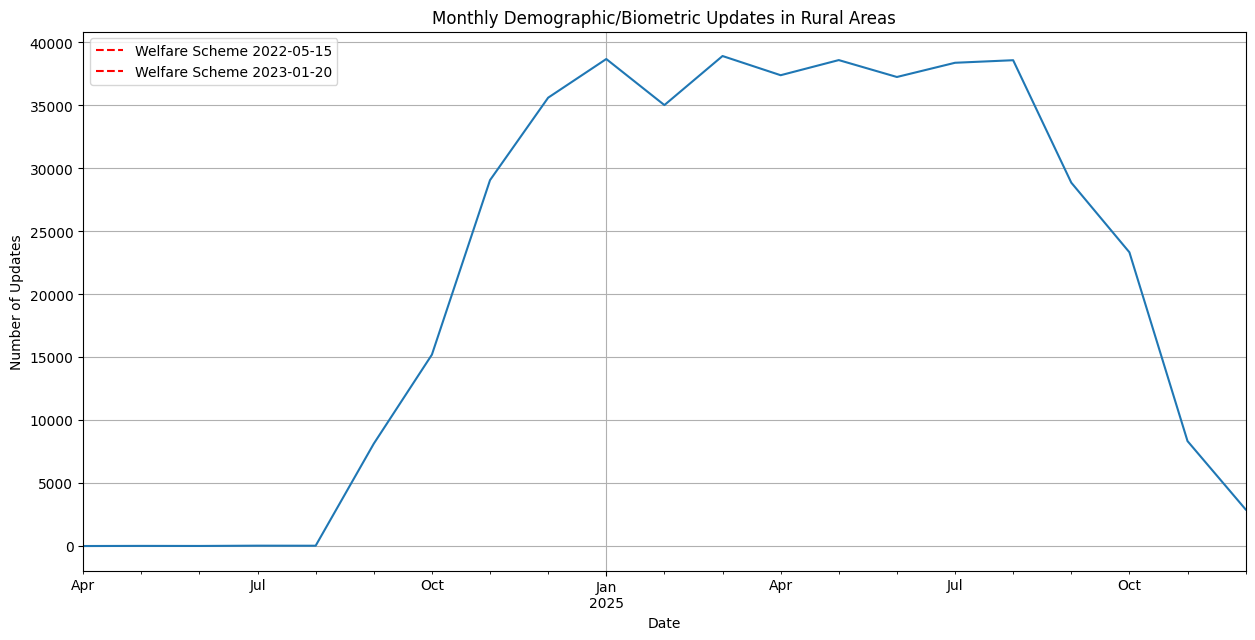

In [17]:
# Assuming 'area_type' (Rural/Urban) and 'update_date' columns exist.
# For demonstration, we'll simulate these columns.
if 'area_type' not in merged_df.columns:
    merged_df['area_type'] = np.random.choice(['Rural', 'Urban'], size=len(merged_df), p=[0.6, 0.4])
if 'update_date' not in merged_df.columns:
    # Dates are in DD-MM-YYYY format; parse explicitly to avoid month/day confusion
    merged_df['update_date'] = pd.to_datetime(merged_df['date'], format='%d-%m-%Y', errors='coerce') - pd.to_timedelta(np.random.randint(0, 365, size=len(merged_df)), unit='d')

rural_updates = merged_df[merged_df['area_type'] == 'Rural'].copy()
rural_updates.set_index('update_date', inplace=True)

# Resample to get monthly update counts
monthly_updates = rural_updates.resample('M').size()

plt.figure(figsize=(15, 7))
monthly_updates.plot(kind='line')
plt.title('Monthly Demographic/Biometric Updates in Rural Areas')
plt.xlabel('Date')
plt.ylabel('Number of Updates')
plt.grid(True)

# Example welfare scheme announcement dates
welfare_dates = [pd.to_datetime('2022-05-15'), pd.to_datetime('2023-01-20')]
for date in welfare_dates:
    plt.axvline(date, color='red', linestyle='--', label=f'Welfare Scheme {date.date()}')

plt.legend()
plt.show()